# TEMPO and CAM-chem-se with UXARRAY directly

First we need to import the driver.

In [1]:
from melodies_monet import driver

In [2]:
# Needed if you want to make changes to `melodies_monet` and don't want to restart kernel:
%load_ext autoreload

%autoreload 2

## Initiate the analysis class

Now lets create an instance of the {mod}`melodies_monet.driver` {class}`~melodies_monet.driver.analysis` class.
It consists of 4 main parts: model instances, observation instances, a paired instance of both.
This will allow us to move things around the plotting function for spatial and overlays and more complex plots.

In [3]:
an = driver.analysis()
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control File

Read in the required yaml control file that sets up all the definitions of what we want to pair and plot.

In [4]:
an.control = '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/control_tempo_l2_no2_cesm_se_20240101.yaml'
an.read_control()
an.control_dict

{'analysis': {'start_time': '2024-01-01',
  'end_time': '2024-01-02',
  'output_dir': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/output/tempo_camchemse',
  'output_dir_save': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/output/tempo_camchemse',
  'output_dir_read': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/output/tempo_camchemse',
  'save': {'paired': {'method': 'netcdf',
    'prefix': '20240101',
    'data': 'all'}},
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'tempo_l2_no2_cesm_se': ['tempo_l2_no2_cesm_se']}}},
  'debug': False},
 'obs': {'tempo_l2_no2': {'debug': False,
   'filename': '/glade/derecho/scratch/jjacdan/TEMPO/TEMPO_NO2_L2_V03_2024010[1]T*.nc',
   'obs_type': 'sat_swath_clm',
   'sat_type': 'tempo_l2_no2',
   'variables': {'main_data_quality_flag': {'main_data_quality

## Load the model data 

The driver will automatically loop through the "models" found in the model section of the control file and create model classes for each. Classes include the label, mapping information, and xarray object as well as the filenames.  Note it can open multiple files easily by including wildcards. Here we are only opening one CAM-chem file.

In [5]:
an.open_models()

Scrip file /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
cesm_se
['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc']
**** Reading CESM SE model output...
Using UXArray grid file: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
Using SCRIP file: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
Opening unstructured grid with UXArray: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc


/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**** Opened uxarray grid: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc


In [6]:
an.models

{'cam-chem-se': model(
     model='cesm_se',
     is_global=False,
     radius_of_influence=1000000.0,
     mod_kwargs={'var_list': ['NO2', 'lat', 'lon', 'lev'], 'scrip_file': '/glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc'},
     file_str=['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc'],
     label='cam-chem-se',
     obj=...,
     extra_calc=None,
     mapping={'tempo_l2_no2': {'NO2': 'vertical_column_troposphere'}},
     variable_dict=None,
     label='cam-chem-se',
     ...
 )}

In [7]:
an.models['cam-chem-se'].obj

<xarray.UxDataset> Size: 538MB
Dimensions:  (z: 32, time: 24, n_face: 174098)
Coordinates:
  * z        (z) float64 256B 992.6 976.3 957.5 936.2 ... 14.36 7.595 3.643
  * time     (time) datetime64[ns] 192B 2024-01-01T01:00:00 ... 2024-01-02
Dimensions without coordinates: n_face
Data variables:
    NO2      (time, z, n_face) float32 535MB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    lat      (n_face) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
    lon      (n_face) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
Attributes: (12/13)
    ne:                         0
    np:                         4
    Conventions:                CF-1.0
    source:                     CAM
    case:                       f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_...
    logname:                    gaubert
    ...                         ...
    initial_file:               /glade/campaign/cesm/cesmdata/inputdata/atm/c...
    topography_file:            /glade/campaign/cesm/cesmdata/inputdata/atm/c...
    model_doi_url:              https://doi.org/10.5065/D67H1H0V
    time_period_freq:           hour_1
    mio_has_unstructured_grid:  True
    mio_scrip_file:             /glade/campaign/acom/MUSICA/grids/ne0CONUSne3...

In [8]:
# All the info in the model class can be called here.
print(an.models['cam-chem-se'].label)
print(an.models['cam-chem-se'].mapping)

cam-chem-se
{'tempo_l2_no2': {'NO2': 'vertical_column_troposphere'}}


In [9]:
# All the info in the analysis class can also be called.
print(an.start_time)
print(an.end_time)
print(an.download_maps)

2024-01-01 00:00:00
2024-01-02 00:00:00
True


## Open Obs

Now for monet-analysis we will open preprocessed data in either netcdf icartt or some other format.  We will not be retrieving data like monetio does for some observations (ie aeronet, airnow, etc....).  Instead we will provide utitilies to do this so that users can add more data easily.

Like models we list all obs objects in the yaml file and it will loop through and create driver.observation instances that include the model type, file, objects (i.e. data object) and label  

In [10]:
an.control_dict['obs']

{'tempo_l2_no2': {'debug': False,
  'filename': '/glade/derecho/scratch/jjacdan/TEMPO/TEMPO_NO2_L2_V03_2024010[1]T*.nc',
  'obs_type': 'sat_swath_clm',
  'sat_type': 'tempo_l2_no2',
  'variables': {'main_data_quality_flag': {'main_data_quality_flag_max': 0,
    'var_applied': ['vertical_column_troposphere']},
   'vertical_column_troposphere': {'ylabel_plot': 'NO2 trop. column'},
   'pressure': {},
   'tropopause_pressure': {},
   'scattering_weights': {},
   'amf_troposphere': {}}}}

In [12]:
an.open_obs()

Reading TEMPO L2
/glade/derecho/scratch/jjacdan/TEMPO/TEMPO_NO2_L2_V03_2024010[1]T*.nc


/glade/u/home/lcthompson/mm/monetio/monetio/monetio/sat/tempo_l2.py:30: UserWarning: Calculating pressure in TEMPO data requires surface_pressure. Adding surface_pressure to output variables
  Returns


In [13]:
# All the info in the observation class can also be called.
an.obs['tempo_l2_no2'].obj

{'2024-01-01T12:51:57Z': <xarray.Dataset> Size: 244MB
 Dimensions:                      (x: 132, y: 2048, time: 132,
                                   swt_level_stagg: 73, swt_level: 72)
 Coordinates:
     lon                          (x, y) float32 1MB nan nan ... -71.65 -71.65
     lat                          (x, y) float32 1MB nan nan nan ... 17.39 17.38
   * time                         (time) datetime64[ns] 1kB 2024-01-01T12:52:1...
 Dimensions without coordinates: x, y, swt_level_stagg, swt_level
 Data variables:
     main_data_quality_flag       (x, y) int16 541kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
     vertical_column_troposphere  (x, y) float64 2MB nan nan nan ... nan nan nan
     pressure                     (swt_level_stagg, x, y) float64 158MB nan .....
     tropopause_pressure          (x, y) float32 1MB nan nan nan ... nan nan nan
     scattering_weights           (x, y, swt_level) float32 78MB nan nan ... nan
     amf_troposphere              (x, y) float32 1MB nan nan nan ..

## Pair model and obs data

In [14]:
%%time

# lat lon are data variables and not coords?? 
model_obj = an.models['cam-chem-se'].obj
model_obj = model_obj.rename({'lon': 'longitude', 'lat': 'latitude'})
model_obj_fixed = model_obj.set_coords(['latitude', 'longitude'])
an.models['cam-chem-se'].obj = model_obj_fixed

# somethibg with the lat lon renaming thing. 
an.pair_data()

1, in pair data


/glade/u/home/lcthompson/mm/MELODIES-MONET/melodies_monet/util/sat_l2_swath_utility_tempo.py:616: UserWarning: 2024-01-01T12:51:57Z granule domain has no overlap with model. Discarding.
  warnings.warn(f"{ref_time} granule domain has no overlap with model. Discarding.")
/glade/u/home/lcthompson/mm/MELODIES-MONET/melodies_monet/util/sat_l2_swath_utility_tempo.py:616: UserWarning: 2024-01-01T12:58:37Z granule domain has no overlap with model. Discarding.
  warnings.warn(f"{ref_time} granule domain has no overlap with model. Discarding.")
/glade/u/home/lcthompson/mm/MELODIES-MONET/melodies_monet/util/sat_l2_swath_utility_tempo.py:616: UserWarning: 2024-01-01T13:05:14Z granule domain has no overlap with model. Discarding.
  warnings.warn(f"{ref_time} granule domain has no overlap with model. Discarding.")
/glade/u/home/lcthompson/mm/MELODIES-MONET/melodies_monet/util/sat_l2_swath_utility_tempo.py:616: UserWarning: 2024-01-01T13:11:52Z granule domain has no overlap with model. Discarding.
 

CPU times: user 372 ms, sys: 114 ms, total: 486 ms
Wall time: 624 ms


IndexError: list index out of range

In [14]:
an.paired

{'airnow_cam-chem-se': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='airnow',
     model='cam-chem-se',
     model_vars=['O3'],
     obs_vars=['OZONE'],
     filename='airnow_cam-chem-se.nc',
 )}

In [15]:
an.paired['airnow_cam-chem-se'].obj

<xarray.Dataset> Size: 920MB
Dimensions:     (time: 2235, x: 2100)
Coordinates:
  * time        (time) datetime64[ns] 18kB 2024-01-01 ... 2024-02-01T00:30:00
  * x           (x) int64 17kB 0 1 2 3 4 5 6 ... 2094 2095 2096 2097 2098 2099
Data variables: (12/35)
    BARPR       (time, x) float64 38MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    BC          (time, x) float64 38MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    CO          (time, x) float64 38MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    NH3         (time, x) float64 38MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    NO          (time, x) float64 38MB -1.0 -1.0 0.3 0.6 ... -1.0 -1.0 -1.0 -1.0
    NO2         (time, x) float64 38MB -1.0 -1.0 -1.0 0.7 ... -1.0 -1.0 -1.0
    ...          ...
    cmsa_name   (x) float64 17kB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0 -1.0
    msa_code    (x) float64 17kB -1.0 -1.0 -1.0 -1.0 ... 3.306e+04 -1.0 -1.0
    msa_name    (x) object 17kB '' '' '' '' ... ' Miami, OK ' '' ''
    state_name  (x) object 17kB 'CC' 'CC' 'CC' 'CC' 'CC' ... '' 'SC' '' '' ''
    epa_region  (x) object 17kB 'CA' 'CA' 'CA' 'CA' ... 'R4' 'R6' 'DSMG' 'DSUZ'
    siteid      (x) object 17kB '000010601' '000020104' ... 'UZB010001'

## Generate plots

Reference std: 12.125726332234919
scrip_file: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
CPU times: user 16.7 s, sys: 4.56 s, total: 21.3 s
Wall time: 25.6 s


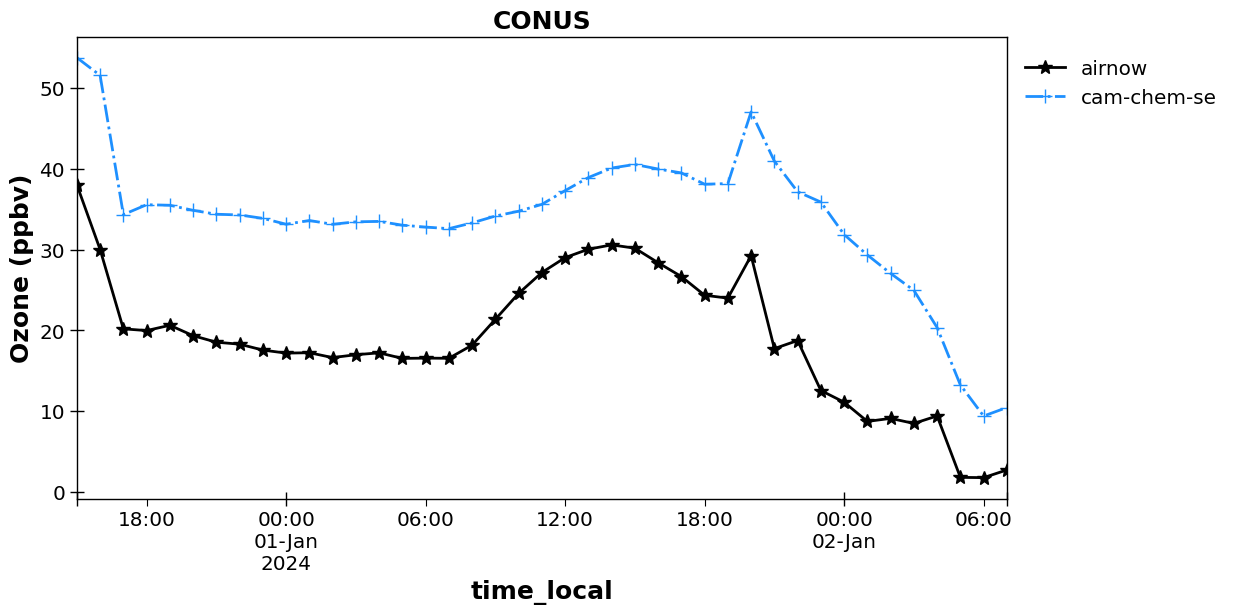

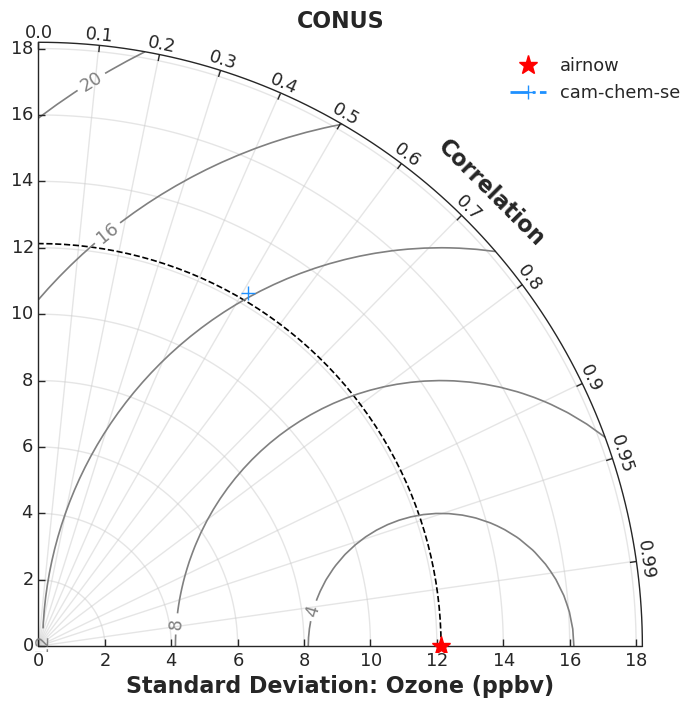

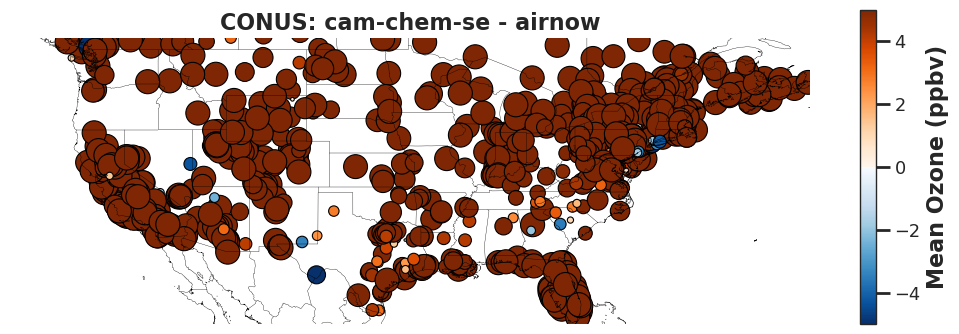

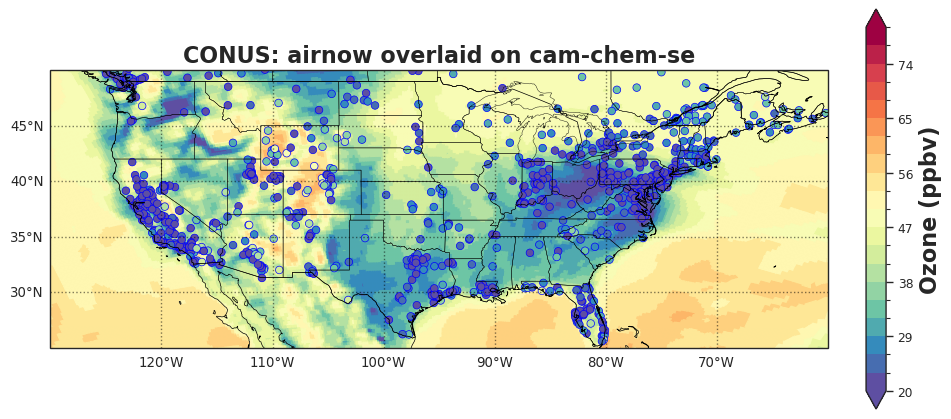

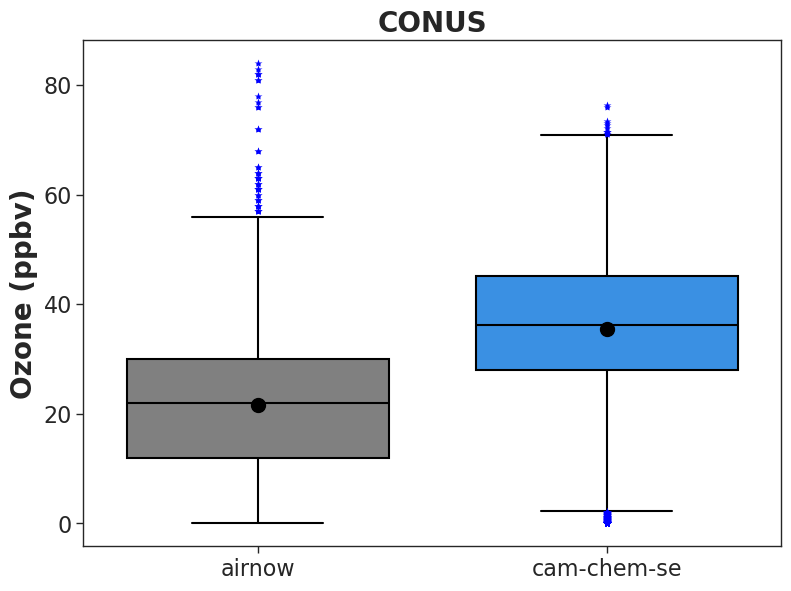

In [16]:
%%time

an.plotting()

**10 Figures**

::::{card-carousel} 10

:::{card} Figure 1
:img-background: output/camchem/plot_grp1.timeseries.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 2
:img-background: output/camchem/plot_grp1.timeseries.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

:::{card} Figure 3
:img-background: output/camchem/plot_grp2.taylor.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 4
:img-background: output/camchem/plot_grp2.taylor.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

:::{card} Figure 5
:img-background: output/camchem/plot_grp3.spatial_bias.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 6
:img-background: output/camchem/plot_grp3.spatial_bias.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 7
:img-background: output/camchem/plot_grp4.spatial_overlay.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 8
:img-background: output/camchem/plot_grp4.spatial_overlay.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 9
:img-background: output/camchem/plot_grp5.boxplot.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 10
:img-background: output/camchem/plot_grp5.boxplot.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

::::